# Хасанова Карина ИУ5-63Б РК1 по ТМО

## Загрузка и первичный анализ данных

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

In [30]:
data = pd.read_csv('Admission_Predict_Ver1.1.csv', sep=",")

In [31]:
data.shape

(500, 9)

In [32]:
data.dtypes

Serial No.             int64
GRE Score              int64
TOEFL Score            int64
University Rating      int64
SOP                  float64
LOR                  float64
CGPA                 float64
Research               int64
Chance of Admit      float64
dtype: object

In [33]:
# проверим есть ли пропущенные значения
data.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [34]:
# Первые 5 строк датасета
data.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [35]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 500


## 1) Масштабирование данных (для одного признака)

In [36]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer

### MinMax масштабирование

In [37]:
sc1 = MinMaxScaler()
sc1_data = sc1.fit_transform(data[['CGPA']])

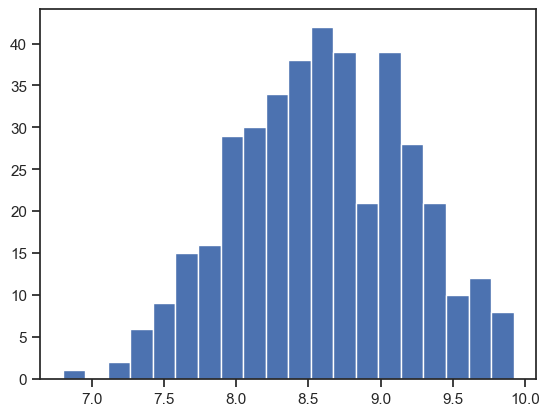

In [16]:
plt.hist(data['CGPA'], 20)
plt.show()

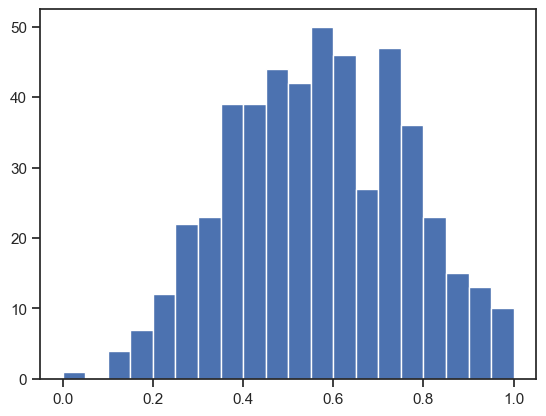

In [38]:
plt.hist(sc1_data, 20)
plt.show()

### Масштабирование данных на основе Z-оценки - StandardScaler

In [39]:
sc2 = StandardScaler()
sc2_data = sc2.fit_transform(data[['CGPA']])

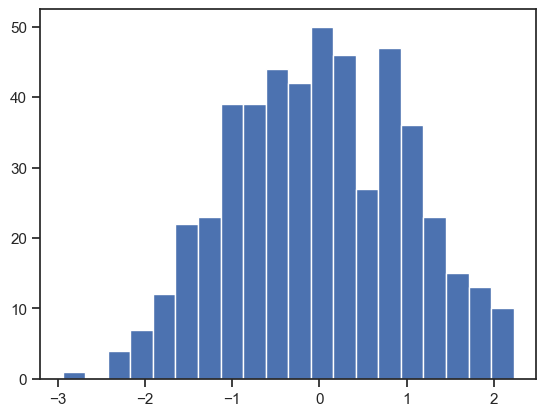

In [40]:
plt.hist(sc2_data, 20)
plt.show()

## 2) Преобразование категориальных признаков в количественные двумя способами (label encoding, one hot encoding) для одного признака

### Использование LabelEncoder

In [41]:
from sklearn.preprocessing import LabelEncoder

In [44]:
data = pd.read_csv('googleplaystore.csv', sep=",")

In [45]:
# Первые 5 строк датасета
data.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [46]:
cat_enc = pd.DataFrame({'c1': data['Genres']})
cat_enc.head()

,c1
0,Art & Design
1,Art & Design;Pretend Play
2,Art & Design
3,Art & Design
4,Art & Design;Creativity


In [47]:
cat_enc['c1'].unique()

array(['Art & Design', 'Art & Design;Pretend Play',
       'Art & Design;Creativity', 'Art & Design;Action & Adventure',
       'Auto & Vehicles', 'Beauty', 'Books & Reference', 'Business',
       'Comics', 'Comics;Creativity', 'Communication', 'Dating',
       'Education;Education', 'Education', 'Education;Creativity',
       'Education;Music & Video', 'Education;Action & Adventure',
       'Education;Pretend Play', 'Education;Brain Games', 'Entertainment',
       'Entertainment;Music & Video', 'Entertainment;Brain Games',
       'Entertainment;Creativity', 'Events', 'Finance', 'Food & Drink',
       'Health & Fitness', 'House & Home', 'Libraries & Demo',
       'Lifestyle', 'Lifestyle;Pretend Play',
       'Adventure;Action & Adventure', 'Arcade', 'Casual', 'Card',
       'Casual;Pretend Play', 'Action', 'Strategy', 'Puzzle', 'Sports',
       'Music', 'Word', 'Racing', 'Casual;Creativity',
       'Casual;Action & Adventure', 'Simulation', 'Adventure', 'Board',
       'Trivia', 'Role 

In [48]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(cat_enc['c1'])

In [49]:
# Наименования категорий в соответствии с порядковыми номерами

# Свойство называется classes, потому что предполагается что мы решаем 
# задачу классификации и каждое значение категории соответствует 
# какому-либо классу целевого признака

le.classes_

array(['Action', 'Action;Action & Adventure', 'Adventure',
       'Adventure;Action & Adventure', 'Adventure;Brain Games',
       'Adventure;Education', 'Arcade', 'Arcade;Action & Adventure',
       'Arcade;Pretend Play', 'Art & Design',
       'Art & Design;Action & Adventure', 'Art & Design;Creativity',
       'Art & Design;Pretend Play', 'Auto & Vehicles', 'Beauty', 'Board',
       'Board;Action & Adventure', 'Board;Brain Games',
       'Board;Pretend Play', 'Books & Reference',
       'Books & Reference;Creativity', 'Books & Reference;Education',
       'Business', 'Card', 'Card;Action & Adventure', 'Card;Brain Games',
       'Casino', 'Casual', 'Casual;Action & Adventure',
       'Casual;Brain Games', 'Casual;Creativity', 'Casual;Education',
       'Casual;Music & Video', 'Casual;Pretend Play', 'Comics',
       'Comics;Creativity', 'Communication', 'Communication;Creativity',
       'Dating', 'Education', 'Education;Action & Adventure',
       'Education;Brain Games', 'Education;C

In [50]:
cat_enc_le

array([ 9, 12,  9, ..., 72, 19, 68], shape=(10841,))

In [51]:
np.unique(cat_enc_le)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119])

In [52]:
le.inverse_transform([0, 1, 2, 3])

array(['Action', 'Action;Action & Adventure', 'Adventure',
       'Adventure;Action & Adventure'], dtype=object)

### Кодирование категорий наборами бинарных значений - one-hot encoding

In [53]:
from sklearn.preprocessing import OneHotEncoder

In [54]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(cat_enc[['c1']])

In [55]:
cat_enc.shape

(10841, 1)

In [56]:
cat_enc_ohe.shape

(10841, 120)

In [57]:
cat_enc_ohe

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10841 stored elements and shape (10841, 120)>

In [58]:
cat_enc_ohe.todense()[0:10]

matrix([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(10, 120))

In [59]:
cat_enc.head(10)

,c1
0,Art & Design
1,Art & Design;Pretend Play
2,Art & Design
3,Art & Design
4,Art & Design;Creativity
5,Art & Design
6,Art & Design
7,Art & Design
8,Art & Design
9,Art & Design;Creativity


In [60]:
pd.get_dummies(cat_enc).head()

,c1_Action,c1_Action;Action & Adventure,c1_Adventure,c1_Adventure;Action & Adventure,c1_Adventure;Brain Games,c1_Adventure;Education,c1_Arcade,c1_Arcade;Action & Adventure,c1_Arcade;Pretend Play,c1_Art & Design,...,c1_Tools;Education,c1_Travel & Local,c1_Travel & Local;Action & Adventure,c1_Trivia,c1_Trivia;Education,c1_Video Players & Editors,c1_Video Players & Editors;Creativity,c1_Video Players & Editors;Music & Video,c1_Weather,c1_Word
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [66]:
df_new = pd.read_csv('googleplaystore.csv')
cat_temp_data = pd.DataFrame({'c1': df_new['Genres']})
pd.get_dummies(cat_temp_data, dummy_na=True).head()

,c1_Action,c1_Action;Action & Adventure,c1_Adventure,c1_Adventure;Action & Adventure,c1_Adventure;Brain Games,c1_Adventure;Education,c1_Arcade,c1_Arcade;Action & Adventure,c1_Arcade;Pretend Play,c1_Art & Design,...,c1_Travel & Local,c1_Travel & Local;Action & Adventure,c1_Trivia,c1_Trivia;Education,c1_Video Players & Editors,c1_Video Players & Editors;Creativity,c1_Video Players & Editors;Music & Video,c1_Weather,c1_Word,c1_nan
0,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Какие методы использовались для решения задачи и почему?

### 1. Для масштабирования данных (признак CGPA) 

Использованные методы:
- MinMaxScaler (нормализация)

- StandardScaler (стандартизация)

**Почему выбраны эти методы:**
- MinMaxScaler:

Приводит данные к диапазону [0, 1], сохраняя исходную структуру распределения

Выбран потому, что признак CGPA уже находится в ограниченном диапазоне (например, от 6 до 10), и нормализация не искажает данные

Подходит для алгоритмов, чувствительных к масштабу (например, метод ближайших соседей, SVM)

- StandardScaler:

Преобразует данные к стандартному нормальному распределению (среднее = 0, std = 1)

Выбран для сравнения с MinMaxScaler и демонстрации альтернативного подхода

Полезен, когда требуется устранить влияние единиц измерения и выбросов

### 2. Для преобразования категориальных признаков (признак Genres)

Использованные методы:
- LabelEncoder (порядковое кодирование)

- OneHotEncoder (One-Hot кодирование)

**Почему выбраны эти методы:**
- LabelEncoder:

Преобразует каждую уникальную категорию в целое число (0, 1, 2, ...)

Выбран из-за простоты реализации и экономии памяти — 10841 строка кодируется одним столбцом

Подходит для древовидных моделей (Random Forest, XGBoost), которые хорошо работают с порядковыми метками

- OneHotEncoder:

Создаёт отдельный бинарный столбец для каждой категории (всего 120 столбцов)

Выбран, так как не создаёт ложной порядковой зависимости между категориями (например, 'Action' не становится "меньше" или "больше" 'Comedy')

Предпочтителен для линейных моделей и нейронных сетей, где важна линейная разделимость признаков